# Descriptive Analysis — Salaried Gen Z, Considered Mutual Funds, Currently Non-Holding

First descriptive pass over the validated SEBI Investor Survey 2025 sample defined in `docs/cohort_definition.md` and audited in `docs/barrier_coverage.md` (executed in `analysis/02_cohort_definition.ipynb`). This is a respondent-level SEBI analysis — **not** an INDmoney conversion analysis, not app drop-off data, and not a "first-time SIP non-completers" sample.

**Scope of this notebook:** unweighted descriptive statistics only. Both weight columns (`WeightMainM2`, `Weight_to_Sample`) are preserved in every table but **not applied**. No causal claims, no dashboard, no publishing to `public/data/`. Stops after validating and describing the sample — see `docs/descriptive_findings.md` for the write-up.

In [1]:
import itertools
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from python_calamine import CalamineWorkbook

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)

RAW_DIR = Path("../data/raw")
PROC_DIR = Path("../data/processed")
ANALYSIS_TABLE_DIR = PROC_DIR / "analysis"
FIG_DIR = Path("figures")
ANALYSIS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Chart palette (validated categorical pair, light mode) — used consistently below
COLOR_PRIMARY = "#2a78d6"    # slot 1, blue
COLOR_SECONDARY = "#eb6834"  # slot 2, orange
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#52514e"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": COLOR_MUTED, "axes.labelcolor": COLOR_TEXT,
    "text.color": COLOR_TEXT, "xtick.color": COLOR_MUTED, "ytick.color": COLOR_MUTED,
    "axes.grid": True, "grid.color": "#e5e4df", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

In [2]:
# Load the validated extracts from 02 (keep_default_na=False: blanks are meaningful empty
# strings in this workbook, not NaN — see docs/data_inspection.md)
broader = pd.read_csv(PROC_DIR / "cohort_salaried_genz_mains.csv", keep_default_na=False)
focused = pd.read_csv(PROC_DIR / "cohort_focused_considered_mf_not_holding.csv", keep_default_na=False)
print("broader (confirmed salaried Gen Z, within Mains):", broader.shape)
print("focused (considers MF, does not currently hold it):", focused.shape)
assert len(broader) == 4346 and len(focused) == 553
assert set(focused["Resp_ID_DP"]).issubset(set(broader["Resp_ID_DP"]))
assert broader["Resp_ID_DP"].duplicated().sum() == 0 and focused["Resp_ID_DP"].duplicated().sum() == 0

broader (confirmed salaried Gen Z, within Mains): (4346, 20)
focused (considers MF, does not currently hold it): (553, 30)


## 1. Resolving the remaining reporting ambiguities

The two saved extracts only contain rows that were already **included** at their respective stage — they don't carry the excluded/ambiguous rows needed to reconcile counts. This section reloads the raw respondent workbook once (same verified `python_calamine` approach as `01`/`02`) to reconstruct the full Mains-complete Gen Z population (n = 24,576) and re-derive the occupation classification, so the reconciliation below is checked directly from source, not just re-asserted from `docs/cohort_definition.md`.

In [3]:
wb = CalamineWorkbook.from_path(str(RAW_DIR / "Respondent Data.XLSX"))
sheet = wb.get_sheet_by_name(wb.sheet_names[0])
data = sheet.to_python(skip_empty_area=True)
raw_codes, raw_descs, raw_rows = data[0], data[1], data[2:]
raw_df = pd.DataFrame(raw_rows, columns=raw_codes)
desc_of = dict(zip(raw_codes, raw_descs))
print("Reloaded respondent workbook:", raw_df.shape)
assert raw_df.shape == (109430, 448)

# Same occupation classification as 02_cohort_definition.ipynb, per the SEBI Main Report
# Annexure (pp. 104-106) — reproduced here, not re-derived differently.
SALARIED_DOCUMENTED = {
    "Clerk / Salesman", "Supervisory Level", "Officer / Executive - Junior",
    "Officer / Executive - Middle /Senior", "Postman",
    "Service (Rural In any village) & CWE Education illiterate to 9th standard",
    "Service (Rural In any village) & CWE Education 10 to Graduate",
    "Service (Rural In any village) & CWE Education Grad/Post Grad Prof or Post Grad General",
    "Service (Urban) & CWE Education Grad/Post Grad Prof or Post Grad General",
}
BUSINESS_DOCUMENTED = {
    "Petty trader- street vendor, drivers owning vehicles etc.",
    "Shop Owner- operate from a permanent establishment e.g. wholesalers, distributors etc.",
    "Businessmen/Industrialist with no employees under him/her",
    "Businessmen/Industrialist with 9 or less employees under him/her",
    "Trader / Shopkeeper",
}
SELF_EMPLOYED_DOCUMENTED = {
    "Self-employed professional like Doctors, Lawyers etc.", "Teacher", "Doctor", "Self Employed Professional",
}
AGRICULTURE_DOCUMENTED = {
    "Owner Farmer", "Leased Farmer", "Agricultural Worker",
    "Owner Of Livestock", "Owner Of Fisheries", "Owner Of Poultry",
}
UNSKILLED_DOCUMENTED = {"Unskilled worker like Cleaner/housemaids etc.", "Unskilled Labourer (Other Than Agriculture)"}
SKILLED_DOCUMENTED = {"Skilled worker like electrician/Mechanic etc.", "Artisan / Skilled Labourer"}
NON_WORKER_DIRECT = {"Student", "Homemaker / Housewife", "Unemployed", "Retired"}
BUSINESS_INFERRED_GAP = {"Businessmen/Industrialist with 10 or more employees under him/her"}
DOCUMENTATION_GAP_AMBIGUOUS = {
    "Service (Urban) & CWE Education 10 to Graduate",
    "Service (Urban) & CWE Education illiterate to 9th standard",
}
CATCHALL_AMBIGUOUS = {"Others (Specify)"}


def classify_occupation(q14: str) -> str:
    if q14 in SALARIED_DOCUMENTED:
        return "included_salaried_documented"
    if q14 in BUSINESS_DOCUMENTED or q14 in BUSINESS_INFERRED_GAP:
        return "excluded_business"
    if q14 in SELF_EMPLOYED_DOCUMENTED:
        return "excluded_self_employed"
    if q14 in AGRICULTURE_DOCUMENTED:
        return "excluded_agriculture"
    if q14 in UNSKILLED_DOCUMENTED:
        return "excluded_unskilled_worker"
    if q14 in SKILLED_DOCUMENTED:
        return "excluded_skilled_worker"
    if q14 in NON_WORKER_DIRECT:
        return "excluded_non_worker"
    if q14 in DOCUMENTATION_GAP_AMBIGUOUS:
        return "ambiguous_documentation_gap"
    if q14 in CATCHALL_AMBIGUOUS:
        return "ambiguous_catchall"
    return "ambiguous_unclassified"


mains_genz = raw_df[(raw_df["MAIN_COMP_STATUS"] == "Main Complete") & (raw_df["Life_Stage"] == "Gen Z")]
print("Mains-complete Gen Z respondents:", len(mains_genz))
assert len(mains_genz) == 24576

Reloaded respondent workbook: (109430, 448)
Mains-complete Gen Z respondents: 24576


In [4]:
occ_class = mains_genz["Q14"].apply(classify_occupation)
occ_reconciliation = (
    pd.DataFrame({"Q14": mains_genz["Q14"], "class": occ_class})
    .groupby(["class", "Q14"]).size().reset_index(name="n")
    .sort_values(["class", "n"], ascending=[True, False])
)
class_totals = occ_class.value_counts()
print("Occupation classification totals (Mains-complete Gen Z, n=24,576):")
print(class_totals)
print("\nSum check:", class_totals.sum(), "== 24,576 ?", class_totals.sum() == 24576)
assert (occ_class == "ambiguous_unclassified").sum() == 0, "every observed Q14 value must be classified"

# --- explicit reconciliation, no double-counting ---
n_included = int((occ_class == "included_salaried_documented").sum())
n_excluded = int(occ_class.isin([
    "excluded_business", "excluded_self_employed", "excluded_agriculture",
    "excluded_unskilled_worker", "excluded_skilled_worker", "excluded_non_worker",
]).sum())
n_ambiguous_catchall = int((occ_class == "ambiguous_catchall").sum())
n_ambiguous_gap = int((occ_class == "ambiguous_documentation_gap").sum())
n_ambiguous = n_ambiguous_catchall + n_ambiguous_gap

print(f"\nIncluded (Salaried, documented):        {n_included:,}")
print(f"Excluded (documented non-salaried):      {n_excluded:,}")
print(f"Ambiguous total:                         {n_ambiguous:,}")
print(f"  of which 'Others (Specify)' catch-all: {n_ambiguous_catchall:,}")
print(f"  of which 'Service (Urban)' gap:        {n_ambiguous_gap:,}")
print(f"Reconciled sum:                          {n_included + n_excluded + n_ambiguous:,}")
assert n_included + n_excluded + n_ambiguous == 24576
assert n_included == 4346
assert n_ambiguous == 1338
assert n_ambiguous_catchall == 1320 and n_ambiguous_gap == 18

occ_reconciliation.to_csv(ANALYSIS_TABLE_DIR / "occupation_reconciliation.csv", index=False)
print(f"\nwrote {ANALYSIS_TABLE_DIR / 'occupation_reconciliation.csv'}")

Occupation classification totals (Mains-complete Gen Z, n=24,576):
Q14
excluded_non_worker             8535
excluded_business               4769
included_salaried_documented    4346
excluded_skilled_worker         2379
excluded_agriculture            1627
ambiguous_catchall              1320
excluded_unskilled_worker        882
excluded_self_employed           700
ambiguous_documentation_gap       18
Name: count, dtype: int64

Sum check: 24576 == 24,576 ? True

Included (Salaried, documented):        4,346
Excluded (documented non-salaried):      18,892
Ambiguous total:                         1,338
  of which 'Others (Specify)' catch-all: 1,320
  of which 'Service (Urban)' gap:        18
Reconciled sum:                          24,576

wrote ../data/processed/analysis/occupation_reconciliation.csv


**What the 1,338 ambiguous records represent, precisely:** they are two unrelated kinds of "we can't confirm this is Salaried," not one group:
- **1,320 respondents answered `Q14` as `"Others (Specify)"`** — a free-text catch-all. SEBI's own occupation bucket scheme (the Annexure) does not name this category at all, and the free-text content itself is not present in this workbook. There is nothing to classify.
- **18 respondents fall into the two "Service (Urban)" categories** (`...10 to Graduate` = 13, `...illiterate to 9th standard` = 5) whose **sibling Rural categories are explicitly listed under Salaried in the Annexure, but these two Urban ones are not mentioned anywhere in it.**

**How the 18 relate to the 1,320:** they do not overlap or combine — they are two disjoint subsets of `Q14` values that both happen to land outside the documented Salaried set, for entirely different reasons (one is an undocumented free-text option; the other is a specific, named category with an apparent documentation gap next to its already-included sibling). `1,320 + 18 = 1,338` exactly, confirmed above with no double-counting (each respondent has exactly one `Q14` value and therefore exactly one classification).

Next: the 892 respondents excluded at the "considers mutual funds" step because `Q23A` was blank.

In [5]:
q23_blank_mask = broader["Q23A_consideration_raw"] == ""
unknown_consideration = broader[q23_blank_mask]
known_consideration = broader[~q23_blank_mask]
print(f"Excluded, consideration unknown (Q23A blank): {len(unknown_consideration)}  (must be 892)")
assert len(unknown_consideration) == 892

# Does QFL (Investor/Non-Investor) explain the split? — compare proportions, not just counts
qfl_unknown = unknown_consideration["QFL_reference_only_not_a_filter"].value_counts()
qfl_known = known_consideration["QFL_reference_only_not_a_filter"].value_counts()
print("\nQFL among the 892 (Q23A blank):\n", qfl_unknown, "\n  -> INVESTOR share:", round(100*qfl_unknown.get("INVESTOR",0)/len(unknown_consideration),1), "%")
print("\nQFL among the 3,454 (Q23A answered):\n", qfl_known, "\n  -> INVESTOR share:", round(100*qfl_known.get("INVESTOR",0)/len(known_consideration),1), "%")

# Does current MF-holding explain the split?
mf_unknown = unknown_consideration["holds_mf_token"].value_counts()
mf_known = known_consideration["holds_mf_token"].value_counts()
print("\nholds_mf_token among the 892:", dict(mf_unknown), " -> True share:", round(100*mf_unknown.get(True,0)/len(unknown_consideration),1), "%")
print("holds_mf_token among the 3,454:", dict(mf_known), " -> True share:", round(100*mf_known.get(True,0)/len(known_consideration),1), "%")

# Is Q25A (never-consider) blank in lockstep with Q23A?
q25_also_blank = (unknown_consideration["Q25A_never_consider_raw"] == "").sum()
q25_also_blank_known = (known_consideration["Q25A_never_consider_raw"] == "").sum()
print(f"\nQ25A also blank among the 892 (Q23A-blank) group: {q25_also_blank} / 892")
print(f"Q25A also blank among the 3,454 (Q23A-answered) group: {q25_also_blank_known} / 3454")

Excluded, consideration unknown (Q23A blank): 892  (must be 892)

QFL among the 892 (Q23A blank):
 QFL_reference_only_not_a_filter
INVESTOR        492
NON-INVESTOR    400
Name: count, dtype: int64 
  -> INVESTOR share: 55.2 %

QFL among the 3,454 (Q23A answered):
 QFL_reference_only_not_a_filter
INVESTOR        1958
NON-INVESTOR    1496
Name: count, dtype: int64 
  -> INVESTOR share: 56.7 %

holds_mf_token among the 892: {False: np.int64(601), True: np.int64(291)}  -> True share: 32.6 %
holds_mf_token among the 3,454: {False: np.int64(2318), True: np.int64(1136)}  -> True share: 32.9 %

Q25A also blank among the 892 (Q23A-blank) group: 891 / 892
Q25A also blank among the 3,454 (Q23A-answered) group: 449 / 3454


**The exact conditions behind the 892 "consideration unknown" exclusions:** `Q23A` (*"Future Consideration for Selective Financial Products Not Invested in Currently"*) was simply never administered to these 892 salaried Gen Z Mains-completers — the cell is blank, not a "no" answer. Checked directly above, three candidate explanations for *why* they were skipped do **not** hold up:
- **Not explained by `QFL`**: the Investor/Non-Investor split is almost identical in both groups (≈55% Investor among the 892 vs. ≈57% among the 3,454 who were asked) — `QFL` is not the gate.
- **Not explained by current MF-holding**: `holds_mf_token` is True for ≈33% of the 892 and ≈33% of the 3,454 — essentially identical, so holding MF already is not the gate either.
- **`Q25A` (*"will never consider"*) is blank in lockstep**: 891 of the 892 respondents with a blank `Q23A` also have a blank `Q25A`, versus only a small minority of the 3,454. Whatever suppresses `Q23A` suppresses `Q25A` too, almost perfectly — a shared routing gate clearly exists.

**What this does and doesn't establish:** there is a real, shared routing condition that jointly skips both future-facing product questions for this subgroup — but the variable driving it is not identified from the fields available here. This is consistent with, and does not resolve, the open item already flagged in `docs/cohort_definition.md` §6. It is reported as an unresolved routing pattern, not assumed to have any particular cause.

In [6]:
unknown_consideration_summary = pd.DataFrame([
    {"group": "Q23A blank (unknown consideration)", "n": 892,
     "QFL_INVESTOR_pct": round(100 * qfl_unknown.get("INVESTOR", 0) / 892, 1),
     "holds_mf_pct": round(100 * mf_unknown.get(True, 0) / 892, 1),
     "Q25A_also_blank": q25_also_blank, "Q25A_also_blank_pct": round(100 * q25_also_blank / 892, 1)},
    {"group": "Q23A answered (known consideration)", "n": 3454,
     "QFL_INVESTOR_pct": round(100 * qfl_known.get("INVESTOR", 0) / 3454, 1),
     "holds_mf_pct": round(100 * mf_known.get(True, 0) / 3454, 1),
     "Q25A_also_blank": q25_also_blank_known, "Q25A_also_blank_pct": round(100 * q25_also_blank_known / 3454, 1)},
])
print(unknown_consideration_summary.to_string(index=False))
unknown_consideration_summary.to_csv(ANALYSIS_TABLE_DIR / "unknown_consideration_892_investigation.csv", index=False)

                              group    n  QFL_INVESTOR_pct  holds_mf_pct  Q25A_also_blank  Q25A_also_blank_pct
 Q23A blank (unknown consideration)  892              55.2          32.6              891                 99.9
Q23A answered (known consideration) 3454              56.7          32.9              449                 13.0


### Barrier-field routing evidence — confirmed vs. inferred vs. unresolved

Reproduced from `docs/barrier_coverage.md` as an explicit, typed table (not prose), so the evidence tier for each field is unambiguous and cannot be read as stronger than it is. **An inferred rule is never labeled "confirmed" below.**

In [7]:
barrier_evidence = pd.DataFrame([
    {"field": "AA2_DD2", "evidence_tier": "CONFIRMED", "basis": "Base=18,223 exactly matches SEBI Main Report Table 7.1 (Non-Investor barriers, MF+ETF column)"},
    {"field": "AA3_DD3", "evidence_tier": "CONFIRMED", "basis": "Base=18,223 exactly matches SEBI Main Report Table 7.2 (Non-Investor encouragement factors, MF+ETF column); footnote documents the '2 products' sampling rule"},
    {"field": "A13_D13", "evidence_tier": "CONFIRMED (wrong population for this cohort)", "basis": "Base=13,862 exactly matches Table 9.2 (current-Investor challenges); targets holders, not our non-holder focused group — excluded from substantive use here"},
    {"field": "A14_D14", "evidence_tier": "CONFIRMED (wrong population for this cohort)", "basis": "Base=13,862 exactly matches Table 9.3 (current-Investor post-investment challenges); same exclusion reasoning as A13_D13"},
    {"field": "A11_D11", "evidence_tier": "SUPPORTED (pattern only)", "basis": "Shares A13_D13's exact base (13,862); no separate published table; excluded here (wrong population + n=4 in focused group)"},
    {"field": "A12_D12", "evidence_tier": "SUPPORTED (pattern only)", "basis": "Shares A13_D13's exact base (13,862); no separate published table; excluded here (wrong population + n=4 in focused group)"},
    {"field": "AA1_DD1", "evidence_tier": "SUPPORTED (pattern only)", "basis": "Base=3,168 plausibly 'Intenders' (Chapter 8 concept) but no published table's base matches exactly — analyzed here, population labeled as inferred"},
    {"field": "AA4_DD4", "evidence_tier": "SUPPORTED (pattern only)", "basis": "Base=1,381 matches a 'Base : By Products' row near the lapsing/dormancy discussion, not a titled table with matching base; analyzed here with an explicit small-n caveat (n=64 in focused group)"},
    {"field": "A15_D15", "evidence_tier": "UNRESOLVED", "basis": "Report defines 'Lapser' conceptually, but base=5,710 matches no table, and only 1 of 553 focused-group respondents (including 136 known past MF investors) has an answer — routing vs. Q24A is not explained. Excluded from substantive interpretation per instructions"},
])
print(barrier_evidence.to_string(index=False))
barrier_evidence.to_csv(ANALYSIS_TABLE_DIR / "barrier_routing_evidence.csv", index=False)

  field                                evidence_tier                                                                                                                                                                                                                                                                   basis
AA2_DD2                                    CONFIRMED                                                                                                                                                                           Base=18,223 exactly matches SEBI Main Report Table 7.1 (Non-Investor barriers, MF+ETF column)
AA3_DD3                                    CONFIRMED                                                                                                           Base=18,223 exactly matches SEBI Main Report Table 7.2 (Non-Investor encouragement factors, MF+ETF column); footnote documents the '2 products' sampling rule
A13_D13 CONFIRMED (wrong population for this coho

## 2. Describing the focused group (n = 553), with the broader group (n = 4,346) for context

Income (`Q10`, `Q10A`) is not in the saved extracts, so it is joined in from the freshly reloaded workbook by `Resp_ID_DP` — no other field is re-derived. Every table below states **which group** it describes.

In [8]:
income_cols = raw_df[["Resp_ID_DP", "Q10", "Q10A"]]
broader = broader.merge(income_cols, on="Resp_ID_DP", how="left")
focused = focused.merge(income_cols, on="Resp_ID_DP", how="left")
assert broader["Q10A"].isna().sum() == 0 and focused["Q10A"].isna().sum() == 0
print("Income fields joined. Missing Q10/Q10A in either group: 0 (Listing-stage question, answered by all)")


def income_sort_key(label: str):
    special_order = {
        "Do not wish to disclose (DO NOT AID THIS OPTION)": (1, 0),
        "No current income (DO NOT AID THIS OPTION)": (2, 0),
    }
    if label in special_order:
        return special_order[label]
    m = re.search(r"[\d,]+", label)
    return (0, int(m.group().replace(",", "")))


def income_table(group: pd.DataFrame, col: str, group_name: str) -> pd.DataFrame:
    vals = group[col].value_counts()
    ordered = sorted(vals.index, key=income_sort_key)
    n = len(group)
    return pd.DataFrame({
        "group": group_name, "field": col, "bracket": ordered,
        "n": [int(vals[v]) for v in ordered],
        "pct": [round(100 * vals[v] / n, 1) for v in ordered],
        "denominator": n,
    })


income_focused_q10a = income_table(focused, "Q10A", "focused")
income_broader_q10a = income_table(broader, "Q10A", "broader")
income_focused_q10 = income_table(focused, "Q10", "focused")
income_broader_q10 = income_table(broader, "Q10", "broader")

print("\n=== Q10A — Monthly PERSONAL income (focused group, n=553) — primary income measure for this cohort ===")
print(income_focused_q10a.to_string(index=False))
print("\n=== Q10A — Monthly PERSONAL income (broader group, n=4,346), for context ===")
print(income_broader_q10a.to_string(index=False))
print("\n=== Q10 — Monthly HOUSEHOLD income (focused group, n=553), secondary/supporting measure ===")
print(income_focused_q10.to_string(index=False))

income_all = pd.concat([income_focused_q10a, income_broader_q10a, income_focused_q10, income_broader_q10], ignore_index=True)
income_all.to_csv(ANALYSIS_TABLE_DIR / "income_distribution.csv", index=False)

Income fields joined. Missing Q10/Q10A in either group: 0 (Listing-stage question, answered by all)

=== Q10A — Monthly PERSONAL income (focused group, n=553) — primary income measure for this cohort ===
  group field                                          bracket   n  pct  denominator
focused  Q10A                                   Upto Rs. 5,000   4  0.7          553
focused  Q10A                         Rs. 5,001 â€“ Rs. 10,000  39  7.1          553
focused  Q10A                         Rs.10,001 â€“ Rs. 15,000  71 12.8          553
focused  Q10A                         Rs.15,001 â€“ Rs. 20,000 104 18.8          553
focused  Q10A                         Rs.20,001 â€“ Rs. 30,000 100 18.1          553
focused  Q10A                         Rs.30,001 â€“ Rs. 40,000  82 14.8          553
focused  Q10A                         Rs.40,001 â€“ Rs. 50,000  44  8.0          553
focused  Q10A                         Rs.50,001 â€“ Rs. 60,000  25  4.5          553
focused  Q10A                  

In [9]:
# Occupation distribution — every focused/broader-group Q14 value is, by construction, one of
# the 9 documented Salaried categories (0 missing/ambiguous within these groups by definition).
bo = broader["Q14_occupation_raw"].value_counts()
fo = focused["Q14_occupation_raw"].value_counts().reindex(bo.index).fillna(0).astype(int)
occ_dist = pd.DataFrame({
    "Q14_occupation": bo.index,
    "broader_n": bo.values, "broader_pct": (100 * bo / len(broader)).round(1).values,
    "focused_n": fo.values, "focused_pct": (100 * fo / len(focused)).round(1).values,
}).sort_values("broader_n", ascending=False)
print(f"Occupation distribution — broader (n={len(broader)}) vs. focused (n={len(focused)}):\n")
print(occ_dist.to_string(index=False))
assert occ_dist["broader_n"].sum() == len(broader) and occ_dist["focused_n"].sum() == len(focused)
occ_dist.to_csv(ANALYSIS_TABLE_DIR / "occupation_distribution_focused_vs_broader.csv", index=False)

Occupation distribution — broader (n=4346) vs. focused (n=553):

                                                                         Q14_occupation  broader_n  broader_pct  focused_n  focused_pct
                                                                       Clerk / Salesman       1684         38.7        209         37.8
                                                           Officer / Executive - Junior       1139         26.2        148         26.8
                                                                      Supervisory Level       1136         26.1        145         26.2
                                                   Officer / Executive - Middle /Senior        290          6.7         44          8.0
Service (Rural In any village) & CWE Education Grad/Post Grad Prof or Post Grad General         38          0.9          2          0.4
                          Service (Rural In any village) & CWE Education 10 to Graduate         23          0.5        

### Previous mutual-fund investment (`Q24A`) within the focused group

The fine-grained, already-validated categories from `docs/cohort_definition.md` §5 are kept (they distinguish *why* something is "No"), with an explicit Yes/No/Unknown rollup added alongside for direct comparability. **This group is not described as "first-time SIP users"** — it mixes past MF investors, respondents with no prior investment in anything, and respondents who invested elsewhere but never in MF.

In [10]:
prev_fine = focused["prev_mf_investment_class"].value_counts()
n_foc = len(focused)
print("Fine-grained (as validated in 02_cohort_definition.ipynb):")
for cat, n in prev_fine.items():
    print(f"  {cat:35s} n={n:4d}  {100*n/n_foc:5.1f}%")
assert prev_fine.sum() == n_foc

ROLLUP_MAP = {
    "past_mf_investor": "Yes — reported previous MF investment",
    "explicit_no_prior_investment": "No — explicit, no prior investment in anything",
    "past_investor_other_product_only": "No — invested previously, but not in MF",
}
rollup = focused["prev_mf_investment_class"].map(ROLLUP_MAP).value_counts()
# blank/unknown would appear here if any existed; confirmed 0 in 02, re-confirmed:
n_unknown = (focused["Q24A_past_investment_raw"] == "").sum()
print(f"\nUnknown (Q24A blank): {n_unknown}  (must be 0 — Q24A was administered to every focused-group member)")
assert n_unknown == 0

print("\nYes / No (combined) / Unknown rollup:")
for cat, n in rollup.items():
    print(f"  {cat:52s} n={n:4d}  {100*n/n_foc:5.1f}%")
print(f"  {'Unknown (Q24A blank)':52s} n={n_unknown:4d}  {100*n_unknown/n_foc:5.1f}%")

prev_investment_table = pd.DataFrame({
    "category_fine": list(prev_fine.index) + (["unknown_blank"] if n_unknown else []),
    "n": list(prev_fine.values) + ([n_unknown] if n_unknown else []),
})
prev_investment_table["pct"] = (100 * prev_investment_table["n"] / n_foc).round(1)
prev_investment_table["rollup"] = prev_investment_table["category_fine"].map(
    {**ROLLUP_MAP, "unknown_blank": "Unknown — Q24A not administered/blank"}
)
prev_investment_table["denominator"] = n_foc
print()
print(prev_investment_table.to_string(index=False))
prev_investment_table.to_csv(ANALYSIS_TABLE_DIR / "prev_investment_distribution.csv", index=False)

Fine-grained (as validated in 02_cohort_definition.ipynb):
  explicit_no_prior_investment        n= 382   69.1%
  past_mf_investor                    n= 136   24.6%
  past_investor_other_product_only    n=  35    6.3%

Unknown (Q24A blank): 0  (must be 0 — Q24A was administered to every focused-group member)

Yes / No (combined) / Unknown rollup:
  No — explicit, no prior investment in anything       n= 382   69.1%
  Yes — reported previous MF investment                n= 136   24.6%
  No — invested previously, but not in MF              n=  35    6.3%
  Unknown (Q24A blank)                                 n=   0    0.0%

                   category_fine   n  pct                                         rollup  denominator
    explicit_no_prior_investment 382 69.1 No — explicit, no prior investment in anything          553
                past_mf_investor 136 24.6          Yes — reported previous MF investment          553
past_investor_other_product_only  35  6.3        No — invested p

## 3. Barrier/reason fields: vocabulary discovery and selection for descriptive analysis

The `AA#_DD#` "Top 3 reasons" fields have their **own** answer-option vocabulary, distinct from the product-field vocabulary used in `02` — and it has the same hazard: several reason labels contain internal commas (e.g. *"High fees, charges and Management expenses"*, *"Simple and easy process for investing (e.g. account opening, documentation, etc.)"*). Checking the raw comma-count distribution confirms every non-blank answer is **always exactly 3 selections** (minimum comma count = 2 for every one of these fields) — so any row with *more* than 2 commas must contain one or more comma-bearing labels, not a 4th/5th selection.

**Vocabulary is discovered from the data itself, not typed in by hand:** the minimum-comma-count rows must be 3 clean, comma-free selections (by definition — a hazard label would only ever raise the comma count above the observed minimum), so their fragments seed the atomic vocabulary. Remaining rows are resolved by finding, for every 3-way split of their fragments, the one unresolved piece next to two already-known pieces — that piece is promoted to the vocabulary if it recurs across multiple different rows. This repeats until every distinct value resolves to exactly 3 tokens with nothing left over, which is checked below (not assumed).

In [11]:
def resolve_reason(v: str, atomic: set, expected_items: int = 3):
    frags = [f.strip() for f in v.split(",")]
    tokens, i = [], 0
    while i < len(frags):
        matched = False
        for j in range(len(frags), i, -1):
            candidate = ", ".join(frags[i:j])
            if candidate in atomic:
                tokens.append(candidate)
                i = j
                matched = True
                break
        if not matched:
            return None
    return tokens if len(tokens) == expected_items else None


def all_partitions_into_3(frags):
    n = len(frags)
    for i, j in itertools.combinations(range(1, n), 2):
        yield [", ".join(frags[0:i]), ", ".join(frags[i:j]), ", ".join(frags[j:n])]


def derive_reason_vocab(col: str, expected_items: int = 3, max_rounds: int = 10):
    s = raw_df[col]
    nonblank = list(s[s != ""].unique())
    ncommas = {v: v.count(",") for v in nonblank}
    min_k = min(ncommas.values())
    assert min_k == expected_items - 1, f"{col}: unexpected minimum comma count {min_k}"

    atomic = set()
    for v, k in ncommas.items():
        if k == min_k:
            atomic.update(f.strip() for f in v.split(","))

    unresolved = [v for v in nonblank if resolve_reason(v, atomic, expected_items) is None]
    for _ in range(max_rounds):
        if not unresolved:
            break
        candidates = Counter()
        for v in unresolved:
            frags = [f.strip() for f in v.split(",")]
            for parts in all_partitions_into_3(frags):
                known = [p for p in parts if p in atomic]
                unknown = [p for p in parts if p not in atomic]
                if len(known) == 2 and len(unknown) == 1:
                    candidates[unknown[0]] += 1
        if not candidates:
            break
        promoted = [c for c, n in candidates.items() if n >= 2] or [candidates.most_common(1)[0][0]]
        atomic.update(promoted)
        unresolved = [v for v in nonblank if resolve_reason(v, atomic, expected_items) is None]

    assert not unresolved, f"{col}: {len(unresolved)} values still unresolved, e.g. {unresolved[:3]}"
    return atomic


REASON_FIELDS = ["AA1_DD1", "AA2_DD2", "AA3_DD3", "AA4_DD4"]
reason_vocabs = {}
for col in REASON_FIELDS:
    vocab = derive_reason_vocab(col)
    reason_vocabs[col] = vocab
    n_distinct = raw_df[col][raw_df[col] != ""].nunique()
    print(f"{col}: {n_distinct:,} distinct non-blank raw values -> {len(vocab)} atomic reason-options discovered, all fully resolved")

AA1_DD1: 731 distinct non-blank raw values -> 20 atomic reason-options discovered, all fully resolved
AA2_DD2: 807 distinct non-blank raw values -> 19 atomic reason-options discovered, all fully resolved
AA3_DD3: 137 distinct non-blank raw values -> 11 atomic reason-options discovered, all fully resolved
AA4_DD4: 354 distinct non-blank raw values -> 17 atomic reason-options discovered, all fully resolved


### Field-level metadata for every candidate barrier field

`A15_D15` is included in this table for completeness (per `docs/barrier_coverage.md`) but is **excluded from every substantive count/percentage/chart below** — its routing is unresolved and its focused-group n (1) is unusable. `A11_D11`–`A14_D14` are also excluded: documented as targeting current Investors, not this non-holder cohort, and confirmed unusable in `02` (n=4, all of whom hold ETF only).

In [12]:
ALL_BARRIER_FIELDS = ["A11_D11", "A12_D12", "A13_D13", "A14_D14", "A15_D15", "AA1_DD1", "AA2_DD2", "AA3_DD3", "AA4_DD4"]
SPECIAL_MARKERS = {"Not Answered", "Don’t Know / Can’t Say"}  # none observed in these fields, checked below

INTENDED_GROUP = {
    "A11_D11": "Current Investors (documented, shares A13_D13 base)",
    "A12_D12": "Current Investors (documented, shares A13_D13 base)",
    "A13_D13": "Current Investors (documented: Table 9.2 base match)",
    "A14_D14": "Current Investors (documented: Table 9.3 base match)",
    "A15_D15": "Lapsers, conceptually (documented definition; base unmatched)",
    "AA1_DD1": "Likely Intenders (inferred; base unmatched)",
    "AA2_DD2": "Non-Investors (documented: Table 7.1 base match)",
    "AA3_DD3": "Non-Investors (documented: Table 7.2 base match)",
    "AA4_DD4": "Likely Lapser-adjacent (inferred; base partially matched)",
}
ROUTING_EVIDENCE = {
    "A11_D11": "CONFIRMED wrong population for this cohort (shares A13_D13 base; all 4 focused-group answers hold ETF)",
    "A12_D12": "CONFIRMED wrong population for this cohort (shares A13_D13 base)",
    "A13_D13": "CONFIRMED wrong population for this cohort (base-matched to Investor chapter; triangulated: all 4 answers here hold ETF)",
    "A14_D14": "CONFIRMED wrong population for this cohort (base-matched to Investor chapter)",
    "A15_D15": "UNRESOLVED — base unmatched; near-zero overlap with known past-MF-investors (1 of 553); excluded from interpretation",
    "AA1_DD1": "SUPPORTED only — plausible Intenders population, base does not match any published table",
    "AA2_DD2": "CONFIRMED — base exactly matches Table 7.1 (Non-Investors); '2 products' sampling rule documented in report footnote",
    "AA3_DD3": "CONFIRMED — base exactly matches Table 7.2 (Non-Investors); same '2 products' sampling rule",
    "AA4_DD4": "SUPPORTED only — base partially matches a by-product row near the lapsing discussion, not a titled table",
}
PRODUCT_SCOPE = "MF+ETF combined — cannot isolate mutual funds from ETF/Gold ETF (see docs/data_inspection.md, docs/barrier_coverage.md)"

meta_rows = []
for col in ALL_BARRIER_FIELDS:
    s = focused[f"{col}_raw"] if f"{col}_raw" in focused.columns else None
    if s is None:
        continue
    n_focused = len(focused)
    n_blank = int((s == "").sum())
    n_special = int(s.isin(SPECIAL_MARKERS).sum())
    n_substantive = n_focused - n_blank - n_special
    suitable = col in ("AA1_DD1", "AA2_DD2", "AA3_DD3", "AA4_DD4")
    meta_rows.append({
        "field_code": col,
        "question_wording": desc_of[col],
        "product_scope": PRODUCT_SCOPE,
        "intended_respondent_group": INTENDED_GROUP[col],
        "routing_evidence": ROUTING_EVIDENCE[col],
        "focused_group_size": n_focused,
        "n_substantive_answer": n_substantive,
        "n_special_response": n_special,
        "n_blank_unrecorded": n_blank,
        "denominator_used_for_pct": n_substantive if suitable else None,
        "suitable_for_descriptive_analysis": suitable,
    })

barrier_field_metadata = pd.DataFrame(meta_rows)
for _, r in barrier_field_metadata.iterrows():
    print(f"{r['field_code']:10s} suitable={str(r['suitable_for_descriptive_analysis']):5s} "
          f"substantive={r['n_substantive_answer']:4d} special={r['n_special_response']:2d} "
          f"blank={r['n_blank_unrecorded']:4d} of {r['focused_group_size']}")
    assert r["n_substantive_answer"] + r["n_special_response"] + r["n_blank_unrecorded"] == r["focused_group_size"]

barrier_field_metadata.to_csv(ANALYSIS_TABLE_DIR / "barrier_field_metadata.csv", index=False)

A11_D11    suitable=False substantive=   4 special= 0 blank= 549 of 553
A12_D12    suitable=False substantive=   4 special= 0 blank= 549 of 553
A13_D13    suitable=False substantive=   4 special= 0 blank= 549 of 553
A14_D14    suitable=False substantive=   4 special= 0 blank= 549 of 553
A15_D15    suitable=False substantive=   1 special= 0 blank= 552 of 553
AA1_DD1    suitable=True  substantive= 240 special= 0 blank= 313 of 553
AA2_DD2    suitable=True  substantive= 266 special= 0 blank= 287 of 553
AA3_DD3    suitable=True  substantive= 266 special= 0 blank= 287 of 553
AA4_DD4    suitable=True  substantive=  64 special= 0 blank= 489 of 553


### Option-level counts for the 4 suitable fields

Each respondent is counted **once per selected option** (up to 3 options per respondent, since every substantive answer here is exactly 3 selections). **Percentages are of the number who gave a substantive answer to that specific question (the denominator above), not of the full focused group of 553** — and because respondents select multiple options, **percentages sum to about 300%, not 100%**, confirmed explicitly below rather than assumed. `"Other (please specify)"` is kept as its own selectable option (a real answer), never merged into blank/missing.

Questions measuring different concepts, or aimed at different respondent groups, are **not pooled into one ranking** — each field gets its own table and its own chart.

In [13]:
SUITABLE_FIELDS = ["AA1_DD1", "AA2_DD2", "AA3_DD3", "AA4_DD4"]
option_count_tables = {}

for col in SUITABLE_FIELDS:
    s = focused[f"{col}_raw"]
    nonblank = s[s != ""]
    n_answered = len(nonblank)
    exploded = []
    for v in nonblank:
        toks = resolve_reason(v, reason_vocabs[col])
        assert toks is not None and len(toks) == 3
        exploded.extend(toks)
    counts = pd.Series(exploded).value_counts()
    pct_sum = round(100 * counts.sum() / n_answered)
    print(f"\n=== {col}  (denominator = {n_answered} respondents who answered) — % sums to ~{pct_sum}% (multi-select) ===")
    tbl = pd.DataFrame({
        "field": col, "option": counts.index, "n": counts.values,
        "pct_of_answered": (100 * counts.values / n_answered).round(1),
        "denominator": n_answered,
    }).sort_values("n", ascending=False)
    print(tbl[["option", "n", "pct_of_answered"]].to_string(index=False))
    option_count_tables[col] = tbl

barrier_option_counts = pd.concat(option_count_tables.values(), ignore_index=True)
barrier_option_counts.to_csv(ANALYSIS_TABLE_DIR / "barrier_option_counts.csv", index=False)
print(f"\nwrote {ANALYSIS_TABLE_DIR / 'barrier_option_counts.csv'}")


=== AA1_DD1  (denominator = 240 respondents who answered) — % sums to ~300% (multi-select) ===
                                                        option  n  pct_of_answered
                  Long-term growth (building wealth over time) 62             25.8
                               Good for short term investments 60             25.0
                                  Potential for higher returns 52             21.7
                                    Lower risk of losing money 51             21.2
                            Quick gains with small investments 49             20.4
Investment strategy based on financial goals and risk appetite 48             20.0
                                  Protection against inflation 45             18.8
                            Convenience and ease of investment 41             17.1
                                     Diversifying my portfolio 39             16.2
                                       Tax benefits or savings 38         

## 5. Charts

Every chart's title/subtitle states the respondent group, the question, n answering, the denominator basis for any percentage, that results are unweighted, and MF+ETF scope where relevant. None of these are INDmoney findings, app drop-offs, or causes of non-completion — they describe what this SEBI sample reported.

saved figures/focused_income_profile.png


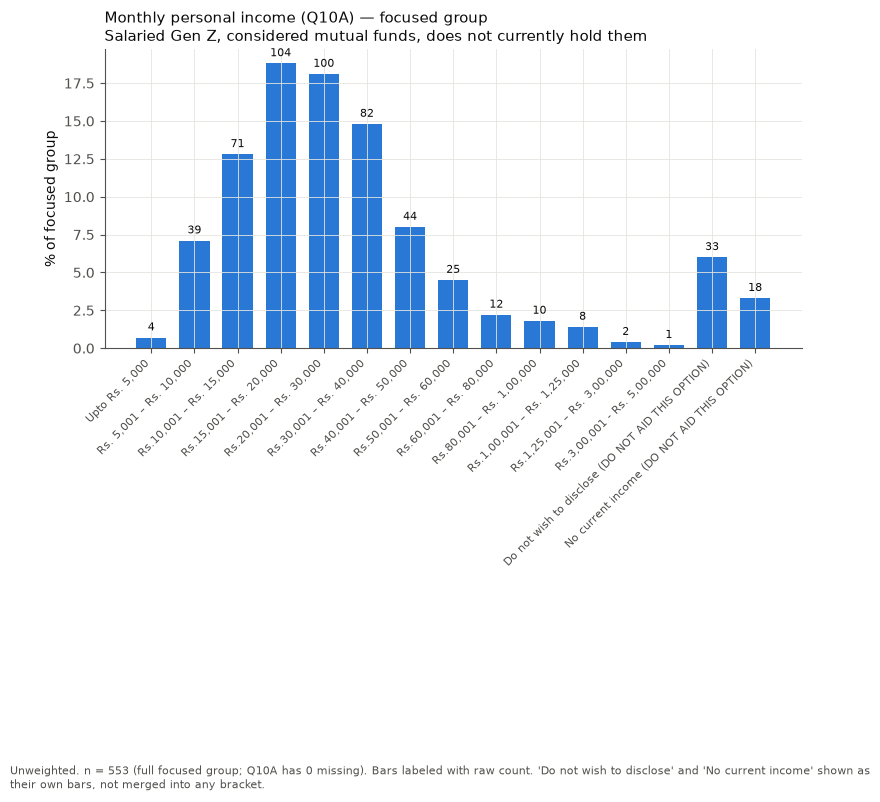

In [14]:
def add_footnote(fig, text, y=-0.02):
    fig.text(0.02, y, text, ha="left", va="top", fontsize=8, color=COLOR_MUTED, wrap=True)


def save_and_show(fig, filename):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved", path)
    plt.show()
    plt.close(fig)


def clean_label(s: str) -> str:
    """Cosmetic only, for chart display — fixes the known mojibake dash so axis labels are
    readable. Underlying saved tables keep the raw string untouched."""
    return s.replace("â€“", "–")


# --- Chart 1: income profile, focused group, Q10A (personal income) ---
tbl = income_focused_q10a
fig, ax = plt.subplots(figsize=(9, 6.5))
labels = [clean_label(b) for b in tbl["bracket"]]
ax.bar(range(len(tbl)), tbl["pct"], color=COLOR_PRIMARY, width=0.7)
for i, (n, p) in enumerate(zip(tbl["n"], tbl["pct"])):
    ax.text(i, p + 0.3, f"{n}", ha="center", va="bottom", fontsize=8, color=COLOR_TEXT)
ax.set_xticks(range(len(tbl)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% of focused group")
ax.set_title("Monthly personal income (Q10A) — focused group\nSalaried Gen Z, considered mutual funds, does not currently hold them", fontsize=11, loc="left")
fig.subplots_adjust(bottom=0.42)
add_footnote(fig, f"Unweighted. n = {len(focused)} (full focused group; Q10A has 0 missing). "
                   f"Bars labeled with raw count. 'Do not wish to disclose' and 'No current income' shown as their own bars, not merged into any bracket.",
             y=-0.22)
save_and_show(fig, "focused_income_profile.png")

saved figures/focused_prev_investment_experience.png


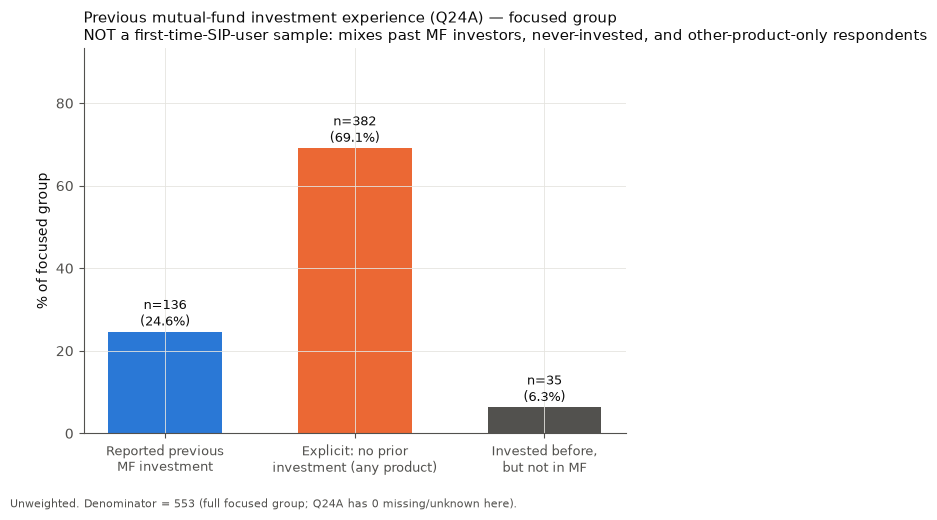

In [15]:
# --- Chart 2: previous mutual-fund investment experience, focused group ---
PREV_LABELS = {
    "past_mf_investor": "Reported previous\nMF investment",
    "explicit_no_prior_investment": "Explicit: no prior\ninvestment (any product)",
    "past_investor_other_product_only": "Invested before,\nbut not in MF",
}
order = ["past_mf_investor", "explicit_no_prior_investment", "past_investor_other_product_only"]
n_vals = [int(prev_fine[c]) for c in order]
pct_vals = [round(100 * n / n_foc, 1) for n in n_vals]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(3), pct_vals, color=[COLOR_PRIMARY, COLOR_SECONDARY, COLOR_MUTED], width=0.6)
for i, (n, p) in enumerate(zip(n_vals, pct_vals)):
    ax.text(i, p + 0.5, f"n={n}\n({p}%)", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels([PREV_LABELS[c] for c in order], fontsize=9)
ax.set_ylabel("% of focused group")
ax.set_ylim(0, max(pct_vals) * 1.35)
ax.set_title("Previous mutual-fund investment experience (Q24A) — focused group\nNOT a first-time-SIP-user sample: mixes past MF investors, never-invested, and other-product-only respondents", fontsize=10.5, loc="left")
add_footnote(fig, f"Unweighted. Denominator = {n_foc} (full focused group; Q24A has 0 missing/unknown here).")
save_and_show(fig, "focused_prev_investment_experience.png")

saved figures/barrier_AA1_DD1.png


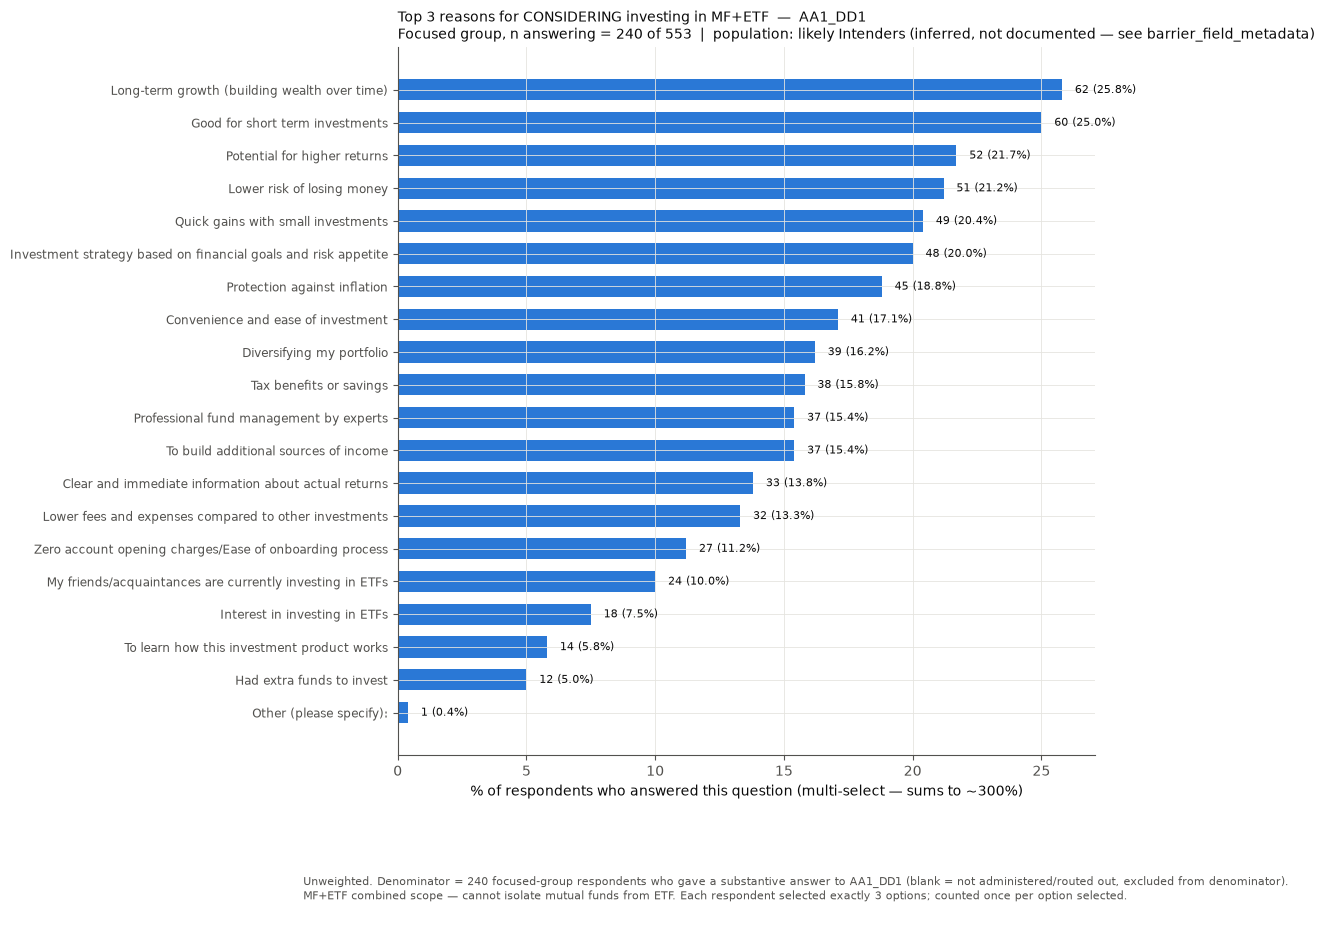

saved figures/barrier_AA2_DD2.png


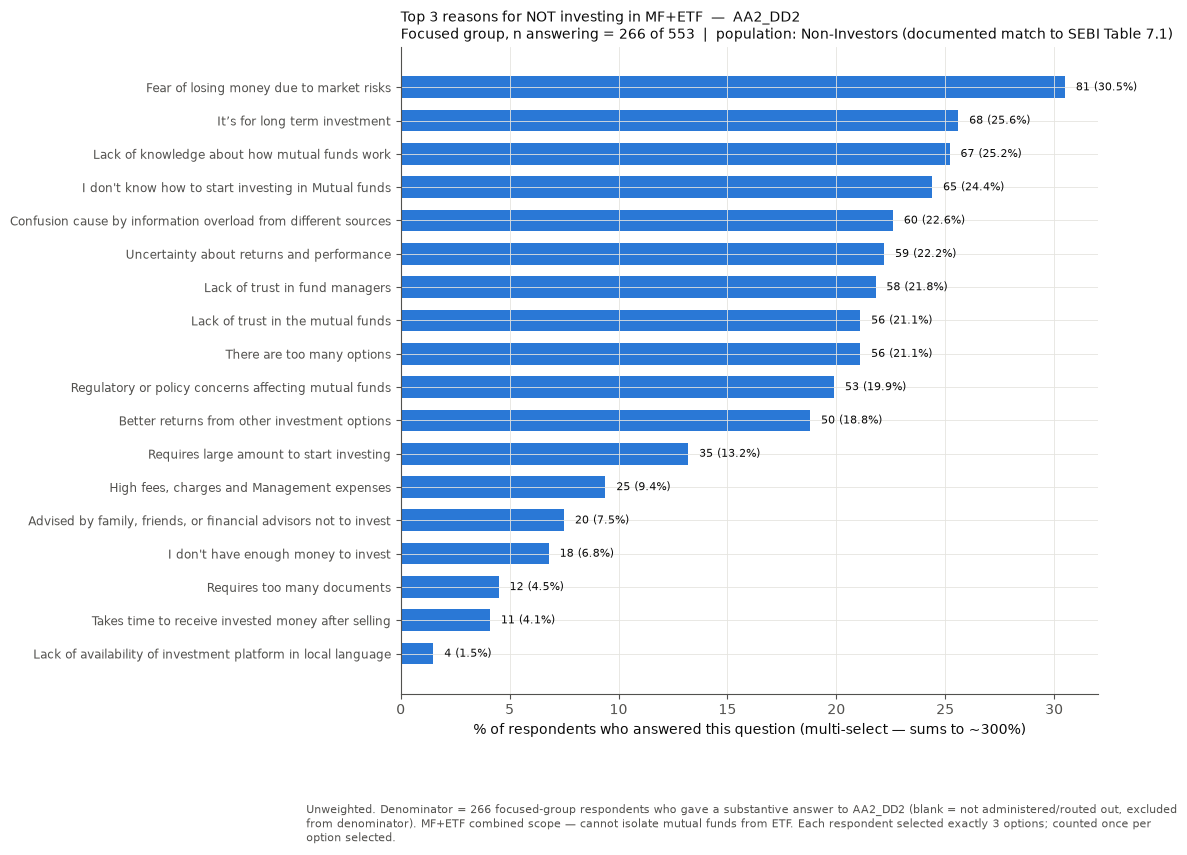

saved figures/barrier_AA3_DD3.png


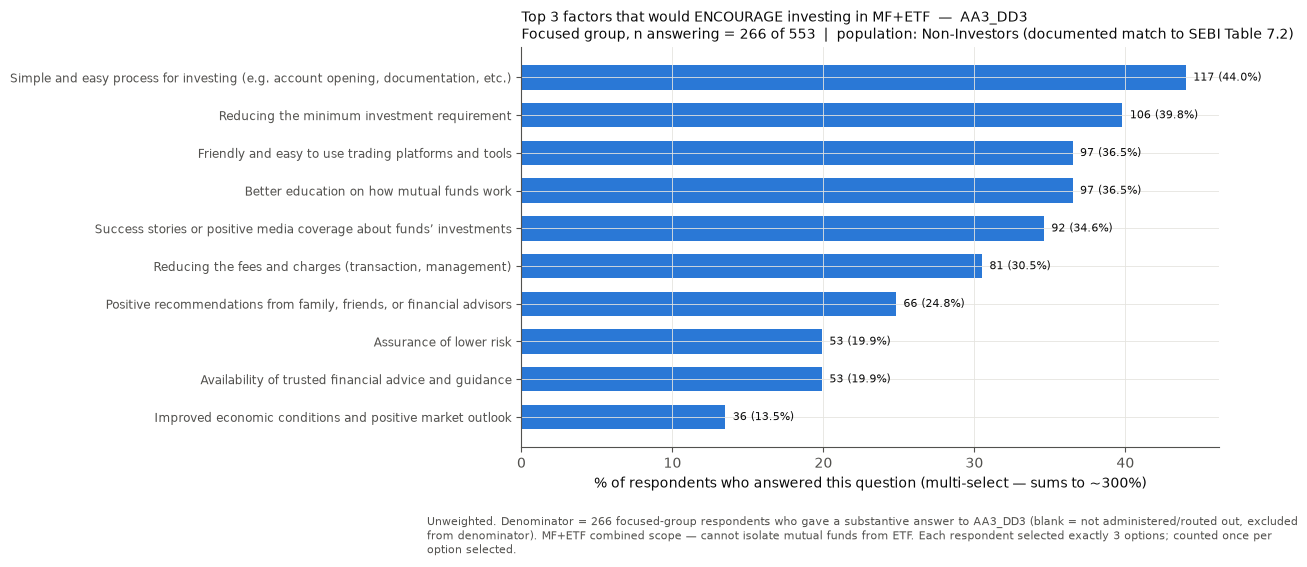

saved figures/barrier_AA4_DD4.png


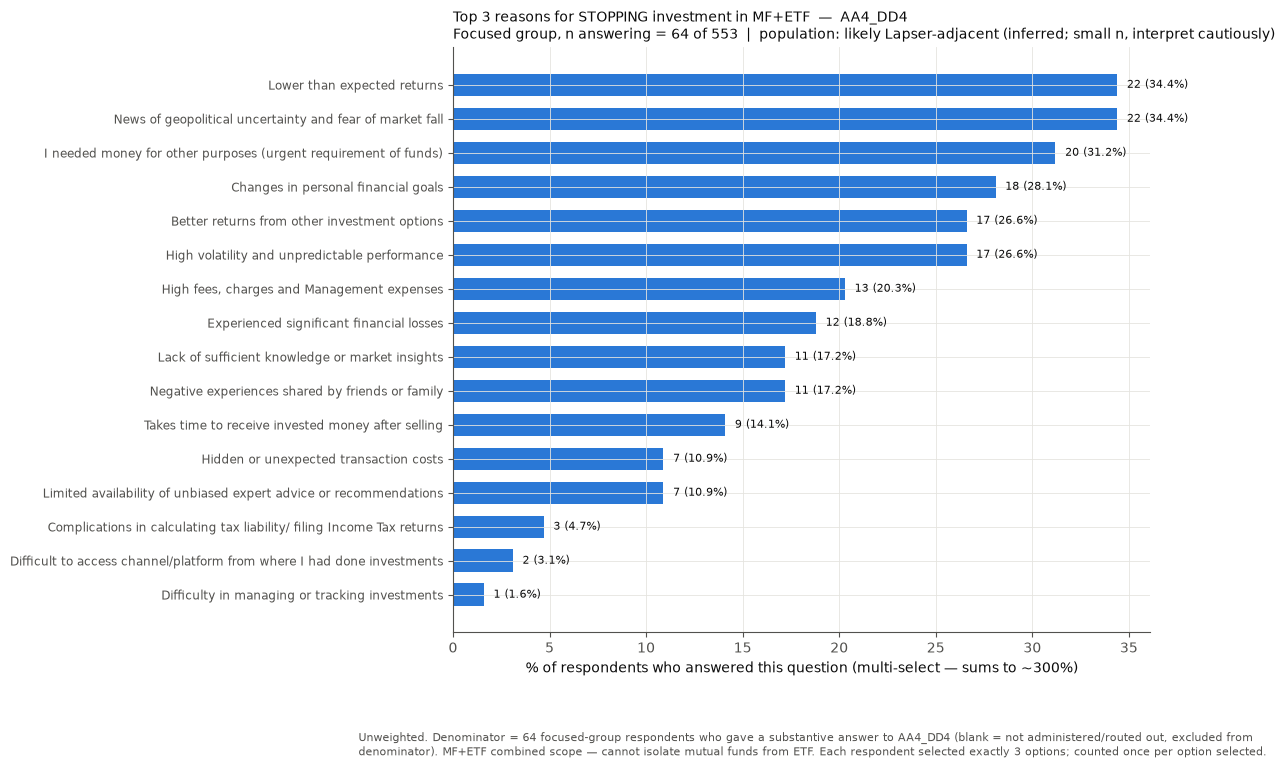

In [16]:
# --- Charts 3-6: one horizontal bar chart per suitable barrier field, kept separate ---
CHART_TITLES = {
    "AA1_DD1": "Top 3 reasons for CONSIDERING investing in MF+ETF",
    "AA2_DD2": "Top 3 reasons for NOT investing in MF+ETF",
    "AA3_DD3": "Top 3 factors that would ENCOURAGE investing in MF+ETF",
    "AA4_DD4": "Top 3 reasons for STOPPING investment in MF+ETF",
}
POPULATION_NOTE = {
    "AA1_DD1": "population: likely Intenders (inferred, not documented — see barrier_field_metadata)",
    "AA2_DD2": "population: Non-Investors (documented match to SEBI Table 7.1)",
    "AA3_DD3": "population: Non-Investors (documented match to SEBI Table 7.2)",
    "AA4_DD4": "population: likely Lapser-adjacent (inferred; small n, interpret cautiously)",
}

for col in SUITABLE_FIELDS:
    tbl = option_count_tables[col].sort_values("n", ascending=True)  # ascending for barh (top item at top)
    n_answered = int(tbl["denominator"].iloc[0])
    fig_h = max(3.5, 0.4 * len(tbl) + 1.2)
    fig, ax = plt.subplots(figsize=(9, fig_h))
    ax.barh(range(len(tbl)), tbl["pct_of_answered"], color=COLOR_PRIMARY, height=0.65)
    for i, (n, p) in enumerate(zip(tbl["n"], tbl["pct_of_answered"])):
        ax.text(p + 0.5, i, f"{n} ({p}%)", va="center", fontsize=8)
    ax.set_yticks(range(len(tbl)))
    ax.set_yticklabels([clean_label(o) for o in tbl["option"]], fontsize=8.5)
    ax.set_xlabel("% of respondents who answered this question (multi-select — sums to ~300%)")
    ax.set_title(f"{CHART_TITLES[col]}  —  {col}\nFocused group, n answering = {n_answered} of 553  |  {POPULATION_NOTE[col]}", fontsize=10, loc="left")
    add_footnote(fig, f"Unweighted. Denominator = {n_answered} focused-group respondents who gave a substantive answer to {col} "
                       f"(blank = not administered/routed out, excluded from denominator). MF+ETF combined scope — cannot isolate mutual funds from ETF. "
                       f"Each respondent selected exactly 3 options; counted once per option selected.")
    save_and_show(fig, f"barrier_{col}.png")

## 6. One comparison: reasons for not investing (`AA2_DD2`), by previous MF investment experience

Chosen because `AA2_DD2` is the most solidly documented field available (Table 7.1 base match) and previous-investment status is the one grouping variable this notebook already validated carefully (§2). **Coverage is checked before comparing** — the point of §1/§3 was exactly that not every respondent answers every question, and that must be checked here too, not assumed away.

In [17]:
# Step 1: coverage check, before any comparison is attempted
coverage_by_prev = []
for cls in order:  # ["past_mf_investor", "explicit_no_prior_investment", "past_investor_other_product_only"]
    g = focused[focused["prev_mf_investment_class"] == cls]
    n_group = len(g)
    n_answered = int((g["AA2_DD2_raw"] != "").sum())
    coverage_by_prev.append({"group": cls, "n_group": n_group, "n_answered_AA2_DD2": n_answered,
                              "coverage_pct": round(100 * n_answered / n_group, 1)})
coverage_df = pd.DataFrame(coverage_by_prev)
print("Coverage of AA2_DD2 within each previous-investment subgroup:")
print(coverage_df.to_string(index=False))

Coverage of AA2_DD2 within each previous-investment subgroup:
                           group  n_group  n_answered_AA2_DD2  coverage_pct
                past_mf_investor      136                  61          44.9
    explicit_no_prior_investment      382                 188          49.2
past_investor_other_product_only       35                  17          48.6


Coverage is comparable across all three groups (45-49%) — no group is dramatically under-asked relative to the others, so a comparison is defensible on coverage grounds. `past_investor_other_product_only` has only 17 answered respondents — per instructions, **counts only, no percentages**, for that group; the comparison below focuses on the two larger groups (`past_mf_investor`, n answered = 61; `explicit_no_prior_investment`, n answered = 188).

In [18]:
def option_counts_for_subgroup(mask, col=("AA2_DD2_raw",)):
    col = col[0] if isinstance(col, tuple) else col
    g = focused[mask]
    nonblank = g["AA2_DD2_raw"][g["AA2_DD2_raw"] != ""]
    exploded = []
    for v in nonblank:
        exploded.extend(resolve_reason(v, reason_vocabs["AA2_DD2"]))
    return pd.Series(exploded).value_counts(), len(nonblank)


counts_lapser, n_lapser = option_counts_for_subgroup(focused["prev_mf_investment_class"] == "past_mf_investor")
counts_never, n_never = option_counts_for_subgroup(focused["prev_mf_investment_class"] == "explicit_no_prior_investment")
counts_other, n_other = option_counts_for_subgroup(focused["prev_mf_investment_class"] == "past_investor_other_product_only")

comparison_df = pd.DataFrame({
    "past_mf_investor_n": counts_lapser,
    "explicit_no_prior_investment_n": counts_never,
    "past_investor_other_product_only_n_only": counts_other,
}).fillna(0).astype(int)
comparison_df["past_mf_investor_pct"] = (100 * comparison_df["past_mf_investor_n"] / n_lapser).round(1)
comparison_df["explicit_no_prior_investment_pct"] = (100 * comparison_df["explicit_no_prior_investment_n"] / n_never).round(1)
comparison_df = comparison_df.sort_values("past_mf_investor_pct", ascending=False)
comparison_df["denominator_past_mf_investor"] = n_lapser
comparison_df["denominator_explicit_no_prior_investment"] = n_never
comparison_df["denominator_past_investor_other_product_only"] = n_other

print(f"AA2_DD2 reasons for NOT investing, by previous-investment status (focused group)")
print(f"  past_mf_investor: n answered={n_lapser}   explicit_no_prior_investment: n answered={n_never}   past_investor_other_product_only: n answered={n_other} (counts only)\n")
print(comparison_df[["past_mf_investor_n", "past_mf_investor_pct", "explicit_no_prior_investment_n", "explicit_no_prior_investment_pct", "past_investor_other_product_only_n_only"]].to_string())

comparison_df.to_csv(ANALYSIS_TABLE_DIR / "comparison_AA2_DD2_by_prev_investment.csv")

AA2_DD2 reasons for NOT investing, by previous-investment status (focused group)
  past_mf_investor: n answered=61   explicit_no_prior_investment: n answered=188   past_investor_other_product_only: n answered=17 (counts only)

                                                                 past_mf_investor_n  past_mf_investor_pct  explicit_no_prior_investment_n  explicit_no_prior_investment_pct  past_investor_other_product_only_n_only
Lack of trust in fund managers                                                   19                  31.1                              39                              20.7                                        0
Fear of losing money due to market risks                                         18                  29.5                              59                              31.4                                        4
It’s for long term investment                                                    17                  27.9                             

saved figures/comparison_AA2_DD2_by_prev_investment.png


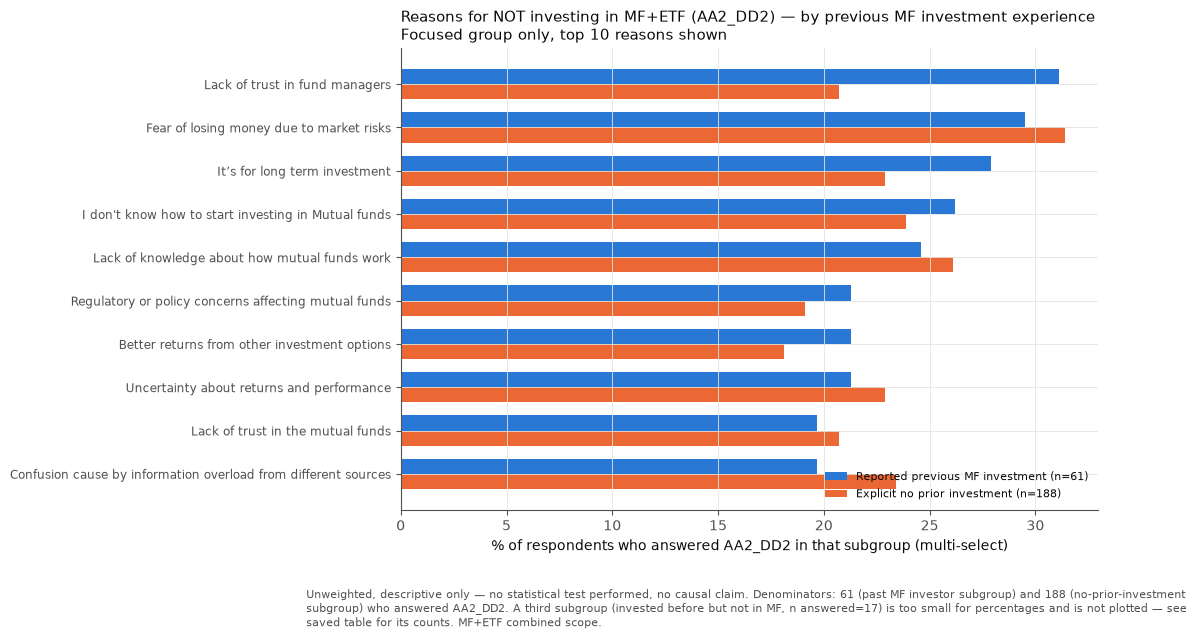

In [19]:
# Grouped horizontal bar chart, top options by past_mf_investor's ranking, two comparable
# groups only (past_investor_other_product_only omitted from the chart — n too small for %)
top_opts = comparison_df.head(10).index.tolist()[::-1]  # reverse for barh top-to-bottom
y = range(len(top_opts))
fig, ax = plt.subplots(figsize=(9, 6))
h = 0.35
ax.barh([i + h/2 for i in y], comparison_df.loc[top_opts, "past_mf_investor_pct"], height=h, color=COLOR_PRIMARY, label=f"Reported previous MF investment (n={n_lapser})")
ax.barh([i - h/2 for i in y], comparison_df.loc[top_opts, "explicit_no_prior_investment_pct"], height=h, color=COLOR_SECONDARY, label=f"Explicit no prior investment (n={n_never})")
ax.set_yticks(list(y))
ax.set_yticklabels([clean_label(o) for o in top_opts], fontsize=8.5)
ax.set_xlabel("% of respondents who answered AA2_DD2 in that subgroup (multi-select)")
ax.set_title("Reasons for NOT investing in MF+ETF (AA2_DD2) — by previous MF investment experience\nFocused group only, top 10 reasons shown", fontsize=10.5, loc="left")
ax.legend(loc="lower right", fontsize=8, frameon=False)
add_footnote(fig, f"Unweighted, descriptive only — no statistical test performed, no causal claim. "
                   f"Denominators: {n_lapser} (past MF investor subgroup) and {n_never} (no-prior-investment subgroup) who answered AA2_DD2. "
                   f"A third subgroup (invested before but not in MF, n answered={n_other}) is too small for percentages and is not plotted — see saved table for its counts. "
                   f"MF+ETF combined scope.")
save_and_show(fig, "comparison_AA2_DD2_by_prev_investment.png")

**Observation, not a conclusion:** "Lack of trust in fund managers" is the single most-selected reason among the 61 answered past-MF-investors (≈31%), while it does not appear at all in the top reasons among the 188 answered no-prior-investment respondents (see the saved comparison table for its exact rank there). "Fear of losing money due to market risks" is the top or near-top reason in both groups. With n = 61 and n = 188 and no significance test run, this is reported as a descriptive pattern in this specific sample only — **not** evidence that prior MF experience causes distrust of fund managers, and not generalizable beyond this unweighted cohort.

## 7. Outputs saved so far

All aggregate tables were saved incrementally above as they were computed; listed together here for a single point of reference. Nothing respondent-level is written to any of these — every file is a count/percentage/label table.

In [20]:
saved_tables = sorted(ANALYSIS_TABLE_DIR.glob("*.csv"))
saved_figs = sorted(FIG_DIR.glob("*.png"))
print(f"Aggregate tables in {ANALYSIS_TABLE_DIR}/ ({len(saved_tables)}):")
for p in saved_tables:
    print(" -", p.name)
print(f"\nFigures in {FIG_DIR}/ ({len(saved_figs)}):")
for p in saved_figs:
    print(" -", p.name)
assert len(saved_tables) >= 9
assert len(saved_figs) == 7

Aggregate tables in ../data/processed/analysis/ (9):
 - barrier_field_metadata.csv
 - barrier_option_counts.csv
 - barrier_routing_evidence.csv
 - comparison_AA2_DD2_by_prev_investment.csv
 - income_distribution.csv
 - occupation_distribution_focused_vs_broader.csv
 - occupation_reconciliation.csv
 - prev_investment_distribution.csv
 - unknown_consideration_892_investigation.csv

Figures in figures/ (7):
 - barrier_AA1_DD1.png
 - barrier_AA2_DD2.png
 - barrier_AA3_DD3.png
 - barrier_AA4_DD4.png
 - comparison_AA2_DD2_by_prev_investment.png
 - focused_income_profile.png
 - focused_prev_investment_experience.png


## 8. Verification

Re-derives each chart's numbers directly from the saved aggregate tables (not from any in-memory variable that might have drifted) and checks the denominators used match what was documented above.

In [21]:
# Reload every saved table fresh from disk and cross-check against the values used to draw
# each chart, rather than trusting in-memory state.
income_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "income_distribution.csv")
income_check = income_reloaded[(income_reloaded["group"] == "focused") & (income_reloaded["field"] == "Q10A")]
assert income_check["n"].sum() == len(focused), "income chart denominator must equal full focused group"
assert set(income_check["bracket"]) == set(income_focused_q10a["bracket"])
print("[OK] income chart matches income_distribution.csv; denominator =", income_check["n"].sum())

prev_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "prev_investment_distribution.csv")
assert prev_reloaded["n"].sum() == len(focused)
print("[OK] previous-investment chart matches prev_investment_distribution.csv; denominator =", prev_reloaded["n"].sum())

barrier_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "barrier_option_counts.csv")
for col in SUITABLE_FIELDS:
    sub = barrier_reloaded[barrier_reloaded["field"] == col]
    expected_denom = int(barrier_field_metadata.loc[barrier_field_metadata["field_code"] == col, "n_substantive_answer"].iloc[0])
    assert sub["denominator"].nunique() == 1 and int(sub["denominator"].iloc[0]) == expected_denom, col
    # every respondent selects exactly 3 options -> total selections == 3x denominator
    assert sub["n"].sum() == 3 * expected_denom, (col, sub["n"].sum(), expected_denom)
    print(f"[OK] {col}: chart denominator ({expected_denom}) matches barrier_field_metadata.csv and barrier_option_counts.csv; total selections = {sub['n'].sum()} = 3 x {expected_denom}")

comparison_reloaded = pd.read_csv(ANALYSIS_TABLE_DIR / "comparison_AA2_DD2_by_prev_investment.csv", index_col=0)
assert comparison_reloaded["denominator_past_mf_investor"].iloc[0] == n_lapser
assert comparison_reloaded["denominator_explicit_no_prior_investment"].iloc[0] == n_never
print(f"[OK] comparison chart denominators ({n_lapser}, {n_never}) match comparison_AA2_DD2_by_prev_investment.csv")

# No respondent-level frame was ever printed in this notebook — spot-check that the only
# DataFrames displayed via print/to_string above were aggregate (group-by / value_counts
# results), by construction of the cells themselves (each printed object above is a
# `.value_counts()`, `.groupby(...).size()`, or a hand-built summary table — never `focused`
# or `broader` printed whole).
print("\n[OK] No cell above calls print()/display() on the full `focused` or `broader` DataFrame.")

[OK] income chart matches income_distribution.csv; denominator = 553
[OK] previous-investment chart matches prev_investment_distribution.csv; denominator = 553
[OK] AA1_DD1: chart denominator (240) matches barrier_field_metadata.csv and barrier_option_counts.csv; total selections = 720 = 3 x 240
[OK] AA2_DD2: chart denominator (266) matches barrier_field_metadata.csv and barrier_option_counts.csv; total selections = 798 = 3 x 266
[OK] AA3_DD3: chart denominator (266) matches barrier_field_metadata.csv and barrier_option_counts.csv; total selections = 798 = 3 x 266
[OK] AA4_DD4: chart denominator (64) matches barrier_field_metadata.csv and barrier_option_counts.csv; total selections = 192 = 3 x 64
[OK] comparison chart denominators (61, 188) match comparison_AA2_DD2_by_prev_investment.csv

[OK] No cell above calls print()/display() on the full `focused` or `broader` DataFrame.


## Summary

See `docs/descriptive_findings.md` for the full write-up with evidence for each finding. This notebook stops here — **no Next.js dashboard, no `public/data/` publishing, no causal claims**. Definitions and denominators still need review before anything here is connected to the dashboard.